In [1]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
import torch.optim as optim
import os

In [2]:
# ==========================================================
# 2. DATA LOADING & PREPROCESSING
# ==========================================================
path = r"D:\Neural Networks\DKHousingPricesSample100k.csv"
dataset_dir = os.path.dirname(path) # Get the directory of the dataset
df = pd.read_csv(path)

features = ["house_type", "sales_type", "year_build", "%_change_between_offer_and_purchase", 
            "no_rooms", "sqm", "city", "area", "region", "nom_interest_rate%", 
            "dk_ann_infl_rate%", "yield_on_mortgage_credit_bonds%"]
target = "purchase_price"

df = df.dropna(subset=features + [target])
X = df[features]
y = df[target].values.reshape(-1, 1)

numeric_features = ["year_build", "%_change_between_offer_and_purchase", "no_rooms", 
                    "sqm", "nom_interest_rate%", "dk_ann_infl_rate%", "yield_on_mortgage_credit_bonds%"]
categorical_features = ["house_type", "sales_type", "city", "area", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X)
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y_scaled, test_size=0.2, random_state=42)

# Convert to PyTorch Tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

In [3]:
# ==========================================================
# 3. MODEL DEFINITIONS
# ==========================================================
def get_model(model_class, input_dim):
    return model_class(input_dim)

class ReLUModel(nn.Module):
    def __init__(self, input_dim):
        super(ReLUModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.ReLU(), nn.Linear(512, 1)
        )
    def forward(self, x): return self.net(x)

class SigmoidModel(nn.Module):
    def __init__(self, input_dim):
        super(SigmoidModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.Sigmoid(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.Sigmoid(), nn.Linear(512, 1)
        )
    def forward(self, x): return self.net(x)

class TanhModel(nn.Module):
    def __init__(self, input_dim):
        super(TanhModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.Tanh(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.Tanh(), nn.Linear(512, 1)
        )
    def forward(self, x): return self.net(x)

class ELUModel(nn.Module):
    def __init__(self, input_dim):
        super(ELUModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ELU(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.ELU(), nn.Linear(512, 1)
        )
    def forward(self, x): return self.net(x)

In [4]:
# ==========================================================
# 4. TRAINING FUNCTION (Saves Best Tanh Model)
# ==========================================================
def train_model(name, model_class, epochs=300):
    model = model_class(X_train.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

    history = {'train_loss': [], 'val_loss': [], 'r2': []}
    best_val_loss = float('inf')
    
    # Path to save the best Tanh model
    save_path = os.path.join(dataset_dir, "best_tanh_model.pth")

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        output = model(X_train_t)
        loss = criterion(output, y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_output = model(X_test_t)
            v_loss = criterion(val_output, y_test_t)
            r2 = r2_score(y_test_t.numpy(), val_output.numpy())

        scheduler.step(v_loss)
        
        # Save best Tanh model logic
        if name == "Tanh" and v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), save_path)

        history['train_loss'].append(loss.item())
        history['val_loss'].append(v_loss.item())
        history['r2'].append(r2)

        if epoch % 100 == 0:
            print(f"{name} - Epoch {epoch:3} | Train Loss: {loss.item():.4f} | Val MSE: {v_loss.item():.4f} | R2: {r2:.4f}")

    if name == "Tanh": print(f"\n>>> Best Tanh model saved at: {save_path}")
    return history

In [5]:
# ==========================================================
# 5. RUN EXPERIMENTS
# ==========================================================
activation_list = [
    ("ReLU", ReLUModel),
    ("Sigmoid", SigmoidModel),
    ("Tanh", TanhModel),
    ("ELU", ELUModel)
]

all_results = {}

for name, m_class in activation_list:
    print(f"\n--- Starting: {name} Model ---")
    all_results[name] = train_model(name, m_class, epochs=300)


--- Starting: ReLU Model ---
ReLU - Epoch 100 | Train Loss: 0.3782 | Val MSE: 0.4380 | R2: 0.5731
ReLU - Epoch 200 | Train Loss: 0.2838 | Val MSE: 0.4338 | R2: 0.5772
ReLU - Epoch 300 | Train Loss: 0.2774 | Val MSE: 0.4339 | R2: 0.5771

--- Starting: Sigmoid Model ---
Sigmoid - Epoch 100 | Train Loss: 0.5596 | Val MSE: 0.5712 | R2: 0.4433
Sigmoid - Epoch 200 | Train Loss: 0.4640 | Val MSE: 0.4925 | R2: 0.5200
Sigmoid - Epoch 300 | Train Loss: 0.4042 | Val MSE: 0.4619 | R2: 0.5498

--- Starting: Tanh Model ---
Tanh - Epoch 100 | Train Loss: 0.4328 | Val MSE: 0.4712 | R2: 0.5408
Tanh - Epoch 200 | Train Loss: 0.3114 | Val MSE: 0.4376 | R2: 0.5735
Tanh - Epoch 300 | Train Loss: 0.2713 | Val MSE: 0.4387 | R2: 0.5724

>>> Best Tanh model saved at: D:\Neural Networks\best_tanh_model.pth

--- Starting: ELU Model ---
ELU - Epoch 100 | Train Loss: 0.4384 | Val MSE: 0.4597 | R2: 0.5520
ELU - Epoch 200 | Train Loss: 0.3610 | Val MSE: 0.4354 | R2: 0.5756
ELU - Epoch 300 | Train Loss: 0.3008 | Val

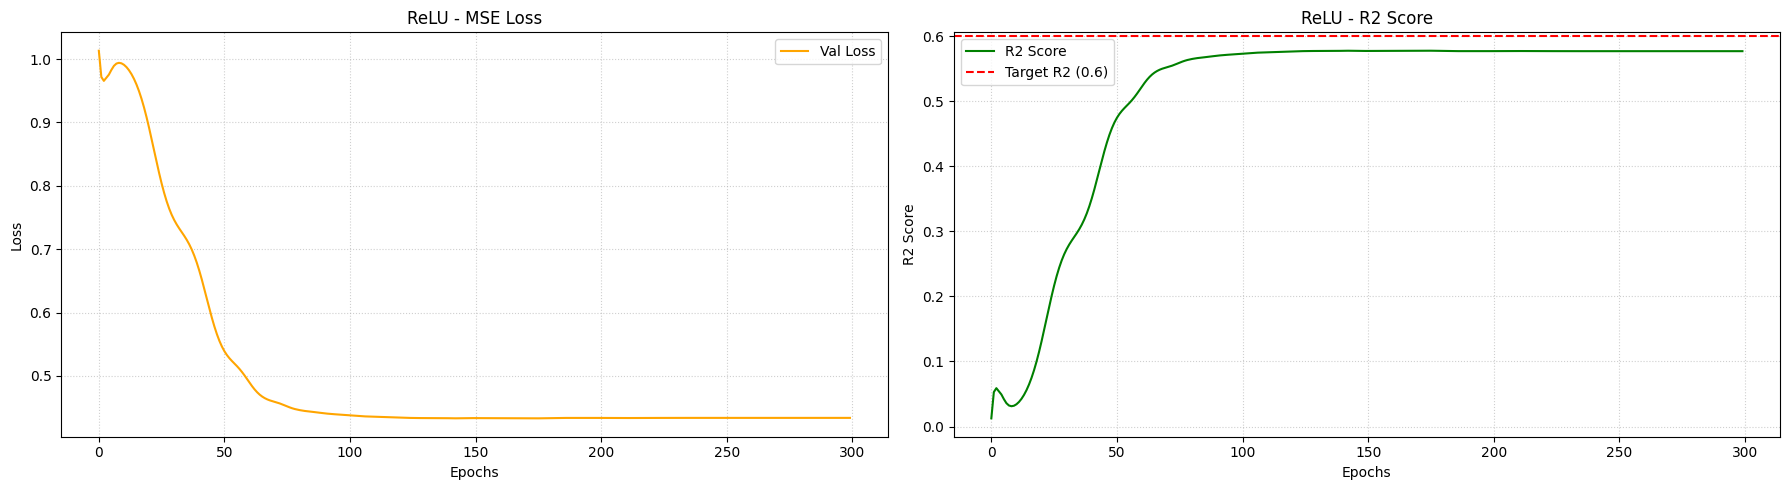

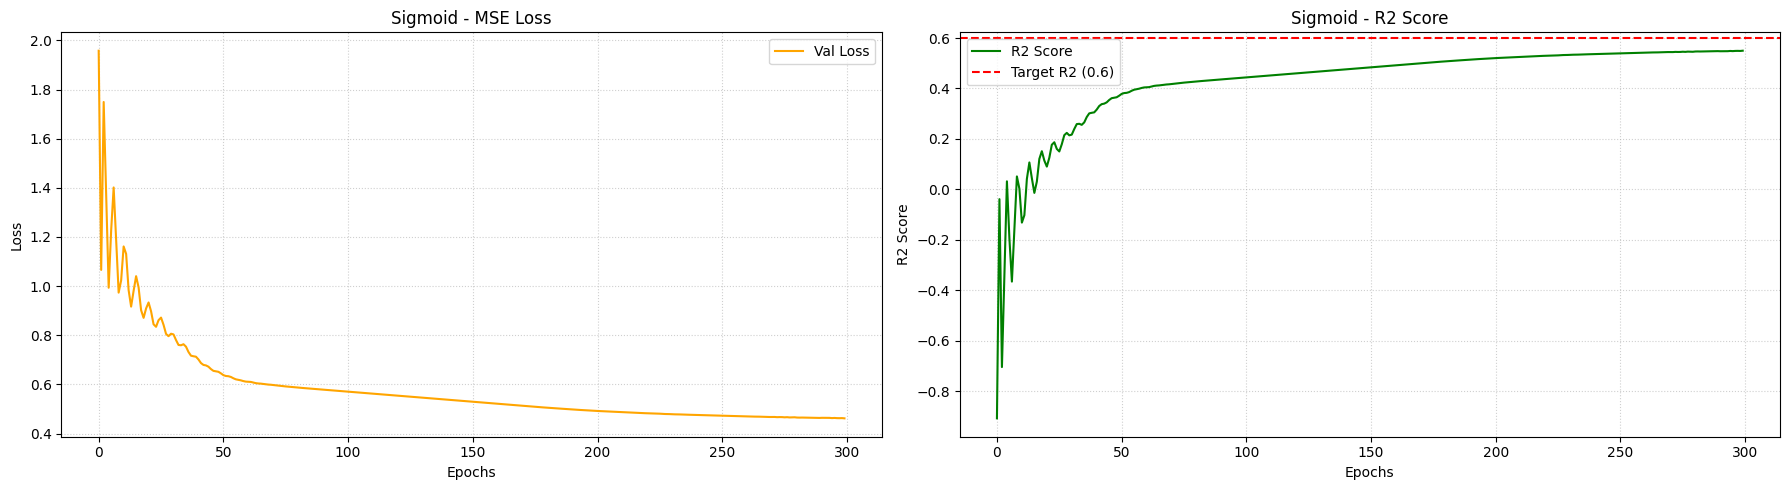

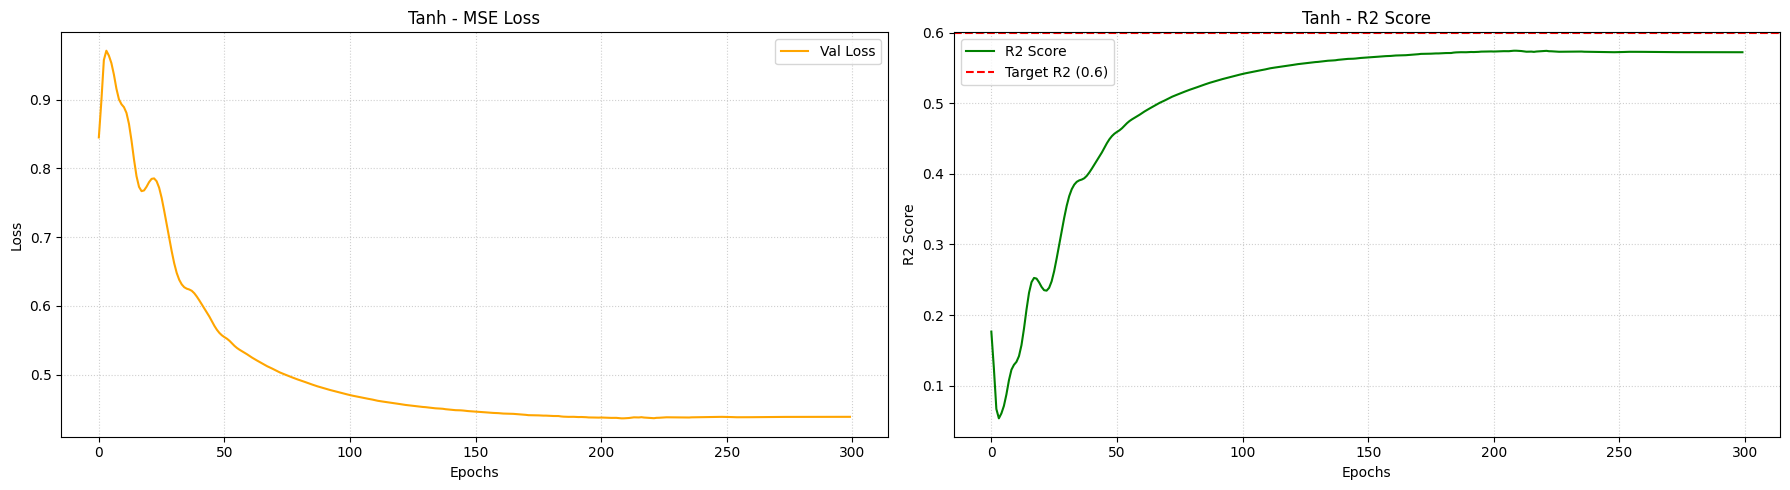

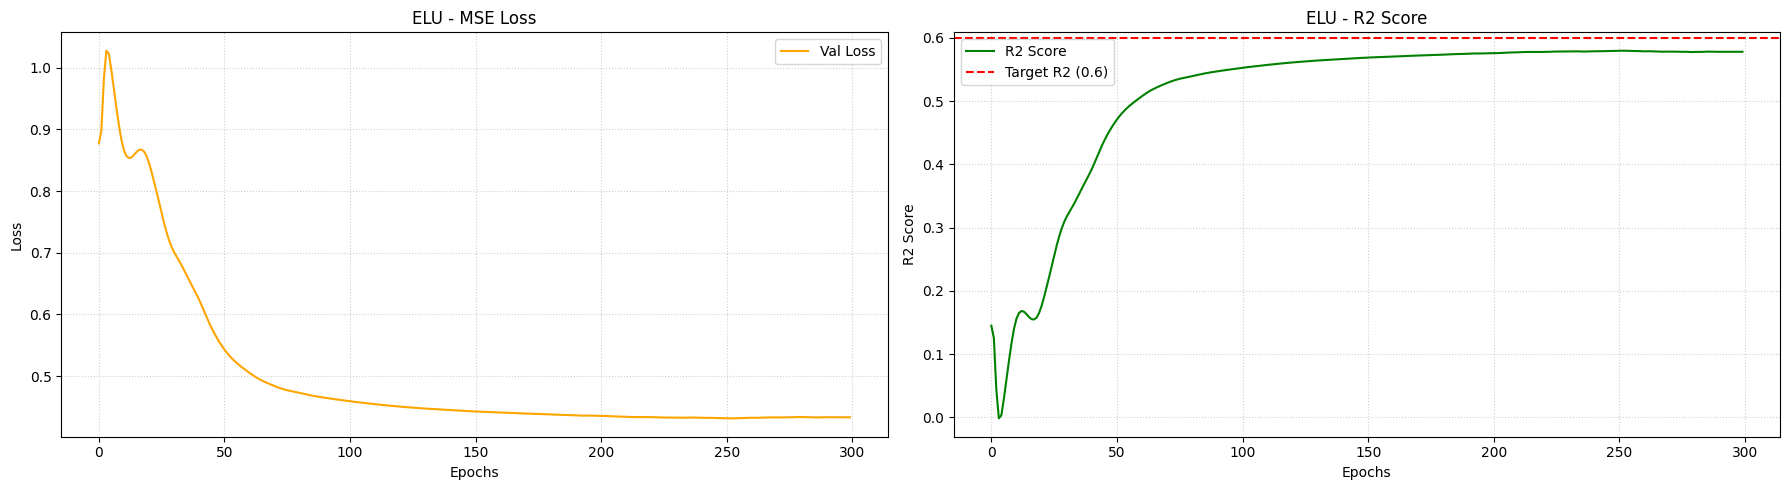

In [7]:
for name, hist in all_results.items():
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 2, 1)
    if 'loss' in hist:
        plt.plot(hist['loss'], label='Train Loss', linestyle='--')
    plt.plot(hist['val_loss'], label='Val Loss', color='orange')
    plt.title(f'{name} - MSE Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(hist['r2'], label='R2 Score', color='green')
    plt.axhline(y=0.6, color='red', linestyle='--', label='Target R2 (0.6)')
    plt.title(f'{name} - R2 Score')
    plt.xlabel('Epochs')
    plt.ylabel('R2 Score')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()